# 09 — Backtesting

**Étape 11 — Backtest (walk-forward + tuning propre)**

Évaluation réaliste par walk-forward backtesting (section 11.2), en
comparant fenêtre expanding et rolling si la structure du marché change fortement.


## Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import data, features, models, backtest, metrics, plots

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (14, 4)


## Définir les fenêtres walk-forward (`src/backtest.py::walk_forward_windows`)

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/processed/dataset_features.csv")

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

SAFE_MODEL_FEATURES = [
    "price_da_lag_1d",
    "price_da_lag_2d",
    "price_da_lag_7d",
    "price_da_rollmean_1d",
    "price_da_rollstd_1d",
    "price_da_rollmean_7d",
    "price_da_rollstd_7d",
    "hour",
    "weekday",
    "is_weekend",
    "month",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "is_holiday",
]

TARGET = "price_da"

# Dataset complet pour la modélisation
model_df = df.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

assert model_df.index.is_unique
assert model_df.index.is_monotonic_increasing
assert model_df.shape == (32672, 42)

# Le backtest commence le 1er janvier 2024 à 00:00,
# exprimé ensuite en UTC.
BACKTEST_START = pd.Timestamp(
    "2024-01-01 00:00",
    tz="Europe/Paris",
).tz_convert("UTC")

# Nombre de journées entre la première ligne complète
# et le début du backtest.
INITIAL_TRAIN_DAYS = int(
    (BACKTEST_START - model_df.index.min())
    / pd.Timedelta(days=1)
)

TEST_DAYS = 30
STEP_DAYS = 30

assert (
    model_df.index.min()
    + pd.Timedelta(days=INITIAL_TRAIN_DAYS)
    == BACKTEST_START
)

expanding_windows = list(
    backtest.walk_forward_windows(
        model_df,
        initial_train_days=INITIAL_TRAIN_DAYS,
        test_days=TEST_DAYS,
        step_days=STEP_DAYS,
        mode="expanding",
    )
)

rolling_windows = list(
    backtest.walk_forward_windows(
        model_df,
        initial_train_days=INITIAL_TRAIN_DAYS,
        test_days=TEST_DAYS,
        step_days=STEP_DAYS,
        mode="rolling",
    )
)

print("Première ligne complète :", model_df.index.min())
print("Début du backtest :", BACKTEST_START)
print("Taille initiale du train :", INITIAL_TRAIN_DAYS, "jours")
print("Fenêtres expanding :", len(expanding_windows))
print("Fenêtres rolling :", len(rolling_windows))

window_preview = []

for mode, windows in {
    "expanding": expanding_windows,
    "rolling": rolling_windows,
}.items():
    for window_id, window in enumerate(windows):
        window_preview.append(
            {
                "mode": mode,
                "window_id": window_id,
                "train_start": window.train_start,
                "train_end_exclusive": window.train_end,
                "test_start": window.test_start,
                "test_end_exclusive": window.test_end,
            }
        )

window_preview = pd.DataFrame(window_preview)

display(
    pd.concat(
        [
            window_preview.groupby("mode").head(2),
            window_preview.groupby("mode").tail(2),
        ]
    )
)

Première ligne complète : 2022-01-07 23:00:00+00:00
Début du backtest : 2023-12-31 23:00:00+00:00
Taille initiale du train : 723 jours
Fenêtres expanding : 21
Fenêtres rolling : 21


,mode,window_id,train_start,train_end_exclusive,test_start,test_end_exclusive
0,expanding,0,2022-01-07 23:00:00+00:00,2023-12-31 23:00:00+00:00,2023-12-31 23:00:00+00:00,2024-01-30 23:00:00+00:00
1,expanding,1,2022-01-07 23:00:00+00:00,2024-01-30 23:00:00+00:00,2024-01-30 23:00:00+00:00,2024-02-29 23:00:00+00:00
21,rolling,0,2022-01-07 23:00:00+00:00,2023-12-31 23:00:00+00:00,2023-12-31 23:00:00+00:00,2024-01-30 23:00:00+00:00
22,rolling,1,2022-02-06 23:00:00+00:00,2024-01-30 23:00:00+00:00,2024-01-30 23:00:00+00:00,2024-02-29 23:00:00+00:00
19,expanding,19,2022-01-07 23:00:00+00:00,2025-07-23 23:00:00+00:00,2025-07-23 23:00:00+00:00,2025-08-22 23:00:00+00:00
20,expanding,20,2022-01-07 23:00:00+00:00,2025-08-22 23:00:00+00:00,2025-08-22 23:00:00+00:00,2025-09-21 23:00:00+00:00
40,rolling,19,2023-07-31 23:00:00+00:00,2025-07-23 23:00:00+00:00,2025-07-23 23:00:00+00:00,2025-08-22 23:00:00+00:00
41,rolling,20,2023-08-30 23:00:00+00:00,2025-08-22 23:00:00+00:00,2025-08-22 23:00:00+00:00,2025-09-21 23:00:00+00:00


## Exécuter le backtest pour chaque modèle (`run_walk_forward`)

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# ---------------------------------------------------------
# Tuning interne : uniquement dans la période pré-2024
# ---------------------------------------------------------

development_df = model_df.loc[
    model_df.index < BACKTEST_START
].copy()

INNER_VALIDATION_DAYS = 90

inner_validation_start = (
    BACKTEST_START
    - pd.Timedelta(days=INNER_VALIDATION_DAYS)
)

inner_train = development_df.loc[
    development_df.index < inner_validation_start
].copy()

inner_validation = development_df.loc[
    development_df.index >= inner_validation_start
].copy()

X_inner_train = inner_train[SAFE_MODEL_FEATURES]
y_inner_train = inner_train[TARGET]

X_inner_validation = inner_validation[SAFE_MODEL_FEATURES]
y_inner_validation = inner_validation[TARGET]

print("Tuning train :", X_inner_train.shape)
print("Tuning validation :", X_inner_validation.shape)
print(
    "Dernière date utilisée pour le tuning :",
    inner_validation.index.max(),
)

assert inner_validation.index.max() < BACKTEST_START


# ---------------------------------------------------------
# Tuning Ridge et Lasso avant 2024
# ---------------------------------------------------------

linear_tuning_rows = []

RIDGE_ALPHAS = [0.1, 1.0, 10.0, 100.0]
LASSO_ALPHAS = [0.01, 0.1, 1.0, 10.0]

for alpha in RIDGE_ALPHAS:
    candidate = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha),
    )

    candidate.fit(X_inner_train, y_inner_train)

    prediction = candidate.predict(X_inner_validation)

    linear_tuning_rows.append(
        {
            "model": "Ridge",
            "alpha": alpha,
            "inner_validation_RMSE": metrics.rmse(
                y_inner_validation,
                prediction,
            ),
        }
    )

for alpha in LASSO_ALPHAS:
    candidate = make_pipeline(
        StandardScaler(),
        Lasso(
            alpha=alpha,
            max_iter=20_000,
        ),
    )

    candidate.fit(X_inner_train, y_inner_train)

    prediction = candidate.predict(X_inner_validation)

    linear_tuning_rows.append(
        {
            "model": "Lasso",
            "alpha": alpha,
            "inner_validation_RMSE": metrics.rmse(
                y_inner_validation,
                prediction,
            ),
        }
    )

linear_tuning = pd.DataFrame(
    linear_tuning_rows
).sort_values(["model", "inner_validation_RMSE"])

display(linear_tuning)

BEST_RIDGE_ALPHA = float(
    linear_tuning.loc[
        linear_tuning["model"] == "Ridge"
    ].iloc[0]["alpha"]
)

BEST_LASSO_ALPHA = float(
    linear_tuning.loc[
        linear_tuning["model"] == "Lasso"
    ].iloc[0]["alpha"]
)

print("Alpha Ridge gelé :", BEST_RIDGE_ALPHA)
print("Alpha Lasso gelé :", BEST_LASSO_ALPHA)


# ---------------------------------------------------------
# Tuning XGBoost avant 2024
# ---------------------------------------------------------

XGB_CANDIDATES = [
    {
        "max_depth": 3,
        "learning_rate": 0.03,
        "n_estimators": 400,
        "min_child_weight": 5,
    },
    {
        "max_depth": 3,
        "learning_rate": 0.03,
        "n_estimators": 600,
        "min_child_weight": 5,
    },
    {
        "max_depth": 4,
        "learning_rate": 0.03,
        "n_estimators": 500,
        "min_child_weight": 5,
    },
]

xgb_tuning_rows = []

for candidate_id, params in enumerate(
    XGB_CANDIDATES,
    start=1,
):
    candidate = models.fit_xgboost(
        X_inner_train,
        y_inner_train,
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    prediction = candidate.predict(X_inner_validation)

    xgb_tuning_rows.append(
        {
            "candidate_id": candidate_id,
            **params,
            "inner_validation_MAE": metrics.mae(
                y_inner_validation,
                prediction,
            ),
            "inner_validation_RMSE": metrics.rmse(
                y_inner_validation,
                prediction,
            ),
        }
    )

xgb_tuning = (
    pd.DataFrame(xgb_tuning_rows)
    .sort_values("inner_validation_RMSE")
    .reset_index(drop=True)
)

display(xgb_tuning)

BEST_XGB_ID = int(
    xgb_tuning.iloc[0]["candidate_id"]
)

BEST_XGB_PARAMS = XGB_CANDIDATES[
    BEST_XGB_ID - 1
].copy()

print("Paramètres XGBoost gelés :", BEST_XGB_PARAMS)


# ---------------------------------------------------------
# Fonctions d'entraînement réutilisées dans chaque fenêtre
# ---------------------------------------------------------

def fit_mean_model(X_train, y_train):
    work = pd.DataFrame(
        {
            "hour": X_train["hour"],
            "price_da": y_train,
        },
        index=X_train.index,
    )

    return work.groupby("hour")["price_da"].mean()


def predict_mean_model(model, X_test):
    return X_test["hour"].map(model).to_numpy()


def fit_ols_model(X_train, y_train):
    model = make_pipeline(
        StandardScaler(),
        LinearRegression(),
    )

    model.fit(X_train, y_train)
    return model


def fit_ridge_model(X_train, y_train):
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=BEST_RIDGE_ALPHA),
    )

    model.fit(X_train, y_train)
    return model


def fit_lasso_model(X_train, y_train):
    model = make_pipeline(
        StandardScaler(),
        Lasso(
            alpha=BEST_LASSO_ALPHA,
            max_iter=20_000,
        ),
    )

    model.fit(X_train, y_train)
    return model


def fit_random_forest_model(X_train, y_train):
    return models.fit_random_forest(
        X_train,
        y_train,
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=42,
    )


def fit_xgboost_model(X_train, y_train):
    return models.fit_xgboost(
        X_train,
        y_train,
        **BEST_XGB_PARAMS,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )


def predict_sklearn_model(model, X_test):
    return model.predict(X_test)


MODEL_SPECS = {
    "Moyenne horaire": (
        ["hour"],
        fit_mean_model,
        predict_mean_model,
    ),
    "OLS": (
        SAFE_MODEL_FEATURES,
        fit_ols_model,
        predict_sklearn_model,
    ),
    "Ridge": (
        SAFE_MODEL_FEATURES,
        fit_ridge_model,
        predict_sklearn_model,
    ),
    "Lasso": (
        SAFE_MODEL_FEATURES,
        fit_lasso_model,
        predict_sklearn_model,
    ),
    "Random Forest": (
        SAFE_MODEL_FEATURES,
        fit_random_forest_model,
        predict_sklearn_model,
    ),
    "XGBoost": (
        SAFE_MODEL_FEATURES,
        fit_xgboost_model,
        predict_sklearn_model,
    ),
}


# ---------------------------------------------------------
# Walk-forward
# ---------------------------------------------------------

walk_forward_results = {}

for mode in ["expanding", "rolling"]:
    print()
    print("Mode :", mode)

    for model_name, (
        feature_columns,
        fit_function,
        predict_function,
    ) in MODEL_SPECS.items():

        print("  Entraînement :", model_name)

        result = backtest.run_walk_forward(
            df=model_df,
            feature_cols=feature_columns,
            target_col=TARGET,
            fit_fn=fit_function,
            predict_fn=predict_function,
            initial_train_days=INITIAL_TRAIN_DAYS,
            test_days=TEST_DAYS,
            step_days=STEP_DAYS,
            mode=mode,
        )

        result["model"] = model_name
        result["mode"] = mode

        walk_forward_results[
            (model_name, mode)
        ] = result

        print(
            "   ",
            len(result),
            "prévisions hors échantillon",
        )

print()
print("Backtests terminés.")

Tuning train : (15185, 18)
Tuning validation : (2159, 18)
Dernière date utilisée pour le tuning : 2023-12-31 22:00:00+00:00


,model,alpha,inner_validation_RMSE
6,Lasso,1.00,31.687072
5,Lasso,0.10,32.615740
4,Lasso,0.01,32.842578
7,Lasso,10.00,33.897989
3,Ridge,100.00,32.578048
2,Ridge,10.00,32.833800
1,Ridge,1.00,32.865854
0,Ridge,0.10,32.869146


Alpha Ridge gelé : 100.0
Alpha Lasso gelé : 1.0


,candidate_id,max_depth,learning_rate,n_estimators,min_child_weight,inner_validation_MAE,inner_validation_RMSE
0,1,3,0.03,400,5,24.419010,30.972832
1,3,4,0.03,500,5,24.302324,31.015627
2,2,3,0.03,600,5,24.462887,31.170112


Paramètres XGBoost gelés : {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 400, 'min_child_weight': 5}

Mode : expanding
  Entraînement : Moyenne horaire
    15113 prévisions hors échantillon
  Entraînement : OLS
    15113 prévisions hors échantillon
  Entraînement : Ridge
    15113 prévisions hors échantillon
  Entraînement : Lasso
    15113 prévisions hors échantillon
  Entraînement : Random Forest
    15113 prévisions hors échantillon
  Entraînement : XGBoost
    15113 prévisions hors échantillon

Mode : rolling
  Entraînement : Moyenne horaire
    15113 prévisions hors échantillon
  Entraînement : OLS
    15113 prévisions hors échantillon
  Entraînement : Ridge
    15113 prévisions hors échantillon
  Entraînement : Lasso
    15113 prévisions hors échantillon
  Entraînement : Random Forest
    15113 prévisions hors échantillon
  Entraînement : XGBoost
    15113 prévisions hors échantillon

Backtests terminés.


## Comparer expanding vs rolling window

,model,mode,MAE,RMSE,sMAPE,Bias,n_obs
0,XGBoost,rolling,18.25,23.90,52.38,-2.50,15113
1,XGBoost,expanding,18.47,24.22,52.45,-3.05,15113
2,Random Forest,rolling,18.57,24.34,53.26,-2.29,15113
3,Random Forest,expanding,18.69,24.79,53.16,-2.99,15113
4,Lasso,rolling,19.65,25.33,55.34,-2.48,15113
5,Ridge,rolling,19.59,25.34,56.09,-2.82,15113
6,OLS,rolling,19.60,25.37,56.18,-2.82,15113
7,Lasso,expanding,20.18,25.82,57.71,-1.78,15113
8,Ridge,expanding,20.56,26.29,58.78,-1.39,15113
9,OLS,expanding,20.58,26.33,58.98,-1.36,15113


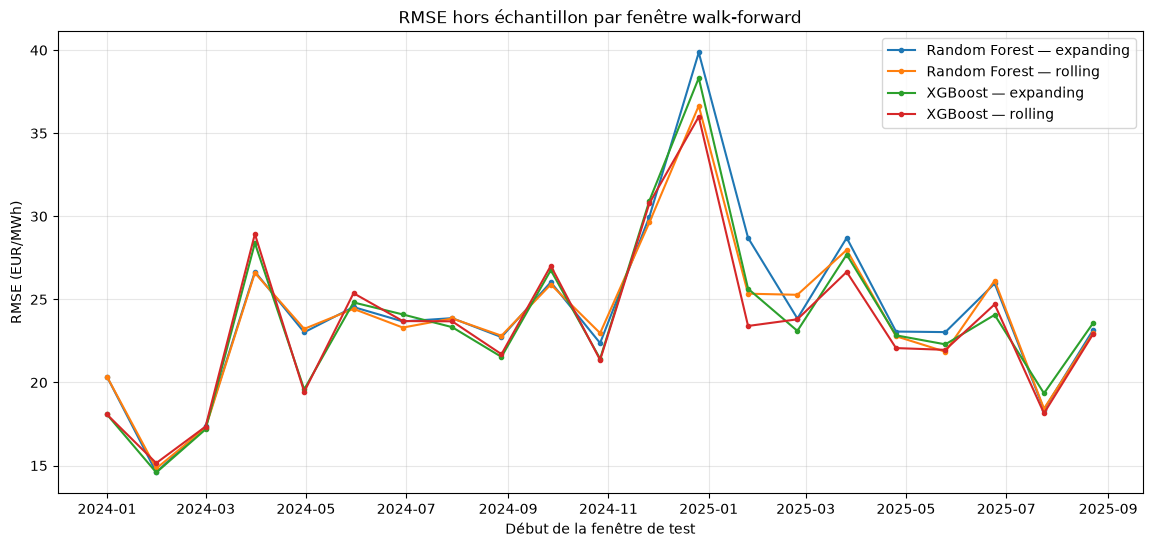

In [4]:
comparison_rows = []
window_metric_rows = []

for (
    model_name,
    mode,
), result in walk_forward_results.items():

    overall = metrics.summary_metrics(
        result["y_true"],
        result["y_pred"],
    )

    comparison_rows.append(
        {
            "model": model_name,
            "mode": mode,
            **overall,
        }
    )

    for window_id, window_data in result.groupby(
        "window_id"
    ):
        window_metrics = metrics.summary_metrics(
            window_data["y_true"],
            window_data["y_pred"],
        )

        window_metric_rows.append(
            {
                "model": model_name,
                "mode": mode,
                "window_id": window_id,
                "test_start": window_data[
                    "datetime"
                ].min(),
                **window_metrics,
            }
        )

walk_forward_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

window_metrics_df = pd.DataFrame(
    window_metric_rows
)

display(
    walk_forward_comparison.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "sMAPE": "{:.2f}",
            "Bias": "{:.2f}",
            "n_obs": "{:.0f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(14, 6))

for (model_name, mode), group in (
    window_metrics_df.groupby(["model", "mode"])
):
    if model_name not in [
        "Random Forest",
        "XGBoost",
    ]:
        continue

    group = group.sort_values("test_start")

    ax.plot(
        group["test_start"],
        group["RMSE"],
        marker="o",
        markersize=3,
        label=f"{model_name} — {mode}",
    )

ax.set_title(
    "RMSE hors échantillon par fenêtre walk-forward"
)
ax.set_xlabel("Début de la fenêtre de test")
ax.set_ylabel("RMSE (EUR/MWh)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Vérifier la checklist anti-leakage (section 11.3) pour tout le pipeline

In [5]:
# ---------------------------------------------------------
# 1. Index temporel
# ---------------------------------------------------------

assert model_df.index.is_unique
assert model_df.index.is_monotonic_increasing


# ---------------------------------------------------------
# 2. Features interdites
# ---------------------------------------------------------

FORBIDDEN_EXACT_COLUMNS = {
    TARGET,
    "negative_price_flag_analysis_only",
    "spike_flag_analysis_only",
    "residual_load_actual_diagnostic",
    "variable_renewables_share_actual_diagnostic",
    "low_nuclear_actual_diagnostic",
    "residual_load_x_gas_actual_diagnostic",
    "low_nuclear_x_demand_actual_diagnostic",
}

forbidden_safe_features = (
    set(SAFE_MODEL_FEATURES)
    & FORBIDDEN_EXACT_COLUMNS
)

assert not forbidden_safe_features, (
    forbidden_safe_features
)

assert not any(
    column.endswith("_diagnostic")
    or column.endswith("_analysis_only")
    for column in SAFE_MODEL_FEATURES
)


# ---------------------------------------------------------
# 3. Tuning antérieur au backtest
# ---------------------------------------------------------

assert inner_validation.index.max() < BACKTEST_START


# ---------------------------------------------------------
# 4. Aucun chevauchement train/test
# ---------------------------------------------------------

for mode, windows in {
    "expanding": expanding_windows,
    "rolling": rolling_windows,
}.items():

    previous_test_end = None

    for window in windows:
        train_index = model_df.loc[
            (
                model_df.index >= window.train_start
            )
            & (
                model_df.index < window.train_end
            )
        ].index

        test_index = model_df.loc[
            (
                model_df.index >= window.test_start
            )
            & (
                model_df.index < window.test_end
            )
        ].index

        assert train_index.intersection(
            test_index
        ).empty

        assert train_index.max() < test_index.min()

        if previous_test_end is not None:
            assert (
                window.test_start
                >= previous_test_end
            )

        previous_test_end = window.test_end


# ---------------------------------------------------------
# 5. Prédictions uniques et hors échantillon
# ---------------------------------------------------------

for key, result in walk_forward_results.items():
    assert not result["datetime"].duplicated().any()
    assert (
        result["datetime"].min()
        >= BACKTEST_START
    )

    assert result[
        ["y_true", "y_pred"]
    ].notna().all().all()


# ---------------------------------------------------------
# 6. Rolling et expanding utilisent les mêmes tests
# ---------------------------------------------------------

for model_name in MODEL_SPECS:
    expanding_dates = set(
        walk_forward_results[
            (model_name, "expanding")
        ]["datetime"]
    )

    rolling_dates = set(
        walk_forward_results[
            (model_name, "rolling")
        ]["datetime"]
    )

    assert expanding_dates == rolling_dates


print("✓ Index trié et unique")
print("✓ Tuning effectué uniquement avant 2024")
print("✓ Aucune cible ou variable réalisée dans les features")
print("✓ Aucun chevauchement train/test")
print("✓ Prédictions hors échantillon et sans doublons")
print("✓ Expanding et rolling comparés sur les mêmes heures")
print("Checklist anti-leakage validée.")

✓ Index trié et unique
✓ Tuning effectué uniquement avant 2024
✓ Aucune cible ou variable réalisée dans les features
✓ Aucun chevauchement train/test
✓ Prédictions hors échantillon et sans doublons
✓ Expanding et rolling comparés sur les mêmes heures
Checklist anti-leakage validée.


## Tableau de benchmark final (toutes baselines + modèles, hors échantillon)

In [6]:
# Toutes les stratégies apprises
all_prediction_indices = []

for result in walk_forward_results.values():
    all_prediction_indices.append(
        pd.DatetimeIndex(result["datetime"])
    )

common_index = all_prediction_indices[0]

for index in all_prediction_indices[1:]:
    common_index = common_index.intersection(index)

common_index = common_index.sort_values()

prediction_table = pd.DataFrame(
    index=common_index
)

prediction_table["y_true"] = model_df.loc[
    common_index,
    TARGET,
]

for (
    model_name,
    mode,
), result in walk_forward_results.items():

    prediction_series = (
        result
        .set_index("datetime")["y_pred"]
        .reindex(common_index)
    )

    prediction_table[
        f"{model_name} — {mode}"
    ] = prediction_series


# Baselines naïves, calculées sur le dataset complet afin
# de pouvoir accéder aux jours précédents.
naive_j1_full = models.naive_persistence(
    df,
    price_col=TARGET,
    day_lag=1,
    timezone="Europe/Paris",
)

naive_j7_full = models.naive_persistence(
    df,
    price_col=TARGET,
    day_lag=7,
    timezone="Europe/Paris",
)

prediction_table["Naive J-1"] = (
    naive_j1_full.reindex(common_index)
)

prediction_table["Naive J-7"] = (
    naive_j7_full.reindex(common_index)
)

prediction_table = prediction_table.dropna()

benchmark_rows = []

for model_name in prediction_table.columns:
    if model_name == "y_true":
        continue

    result = metrics.summary_metrics(
        prediction_table["y_true"],
        prediction_table[model_name],
    )

    benchmark_rows.append(
        {
            "model": model_name,
            **result,
        }
    )

final_walk_forward_benchmark = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

display(
    final_walk_forward_benchmark.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "sMAPE": "{:.2f}",
            "Bias": "{:.2f}",
            "n_obs": "{:.0f}",
        }
    )
)

BENCHMARK_PATH = Path(
    "../data/processed/walk_forward_benchmark.csv"
)

PREDICTIONS_PATH = Path(
    "../data/processed/walk_forward_predictions.csv"
)

final_walk_forward_benchmark.to_csv(
    BENCHMARK_PATH,
    index=False,
)

prediction_table.to_csv(
    PREDICTIONS_PATH,
    index_label="datetime",
)

print(
    "Période évaluée :",
    prediction_table.index.min(),
    "→",
    prediction_table.index.max(),
)

print(
    "Nombre d'heures communes :",
    len(prediction_table),
)

print("Benchmark sauvegardé :", BENCHMARK_PATH.resolve())
print("Prédictions sauvegardées :", PREDICTIONS_PATH.resolve())

,model,MAE,RMSE,sMAPE,Bias,n_obs
0,XGBoost — rolling,18.25,23.90,52.38,-2.50,15113
1,XGBoost — expanding,18.47,24.22,52.45,-3.05,15113
2,Random Forest — rolling,18.57,24.34,53.26,-2.29,15113
3,Random Forest — expanding,18.69,24.79,53.16,-2.99,15113
4,Lasso — rolling,19.65,25.33,55.34,-2.48,15113
5,Ridge — rolling,19.59,25.34,56.09,-2.82,15113
6,OLS — rolling,19.60,25.37,56.18,-2.82,15113
7,Lasso — expanding,20.18,25.82,57.71,-1.78,15113
8,Ridge — expanding,20.56,26.29,58.78,-1.39,15113
9,OLS — expanding,20.58,26.33,58.98,-1.36,15113


Période évaluée : 2023-12-31 23:00:00+00:00 → 2025-09-21 22:00:00+00:00
Nombre d'heures communes : 15113
Benchmark sauvegardé : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/data/processed/walk_forward_benchmark.csv
Prédictions sauvegardées : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/data/processed/walk_forward_predictions.csv


## Visualisation prévision vs réel sur les fenêtres de test

Meilleur modèle walk-forward : XGBoost — rolling


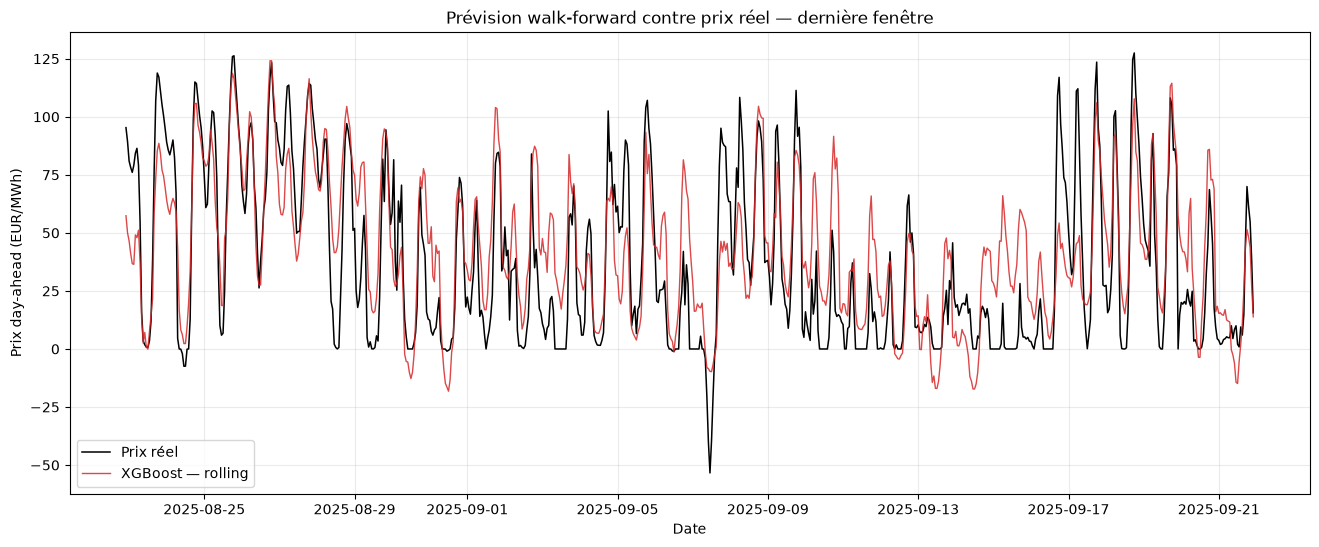

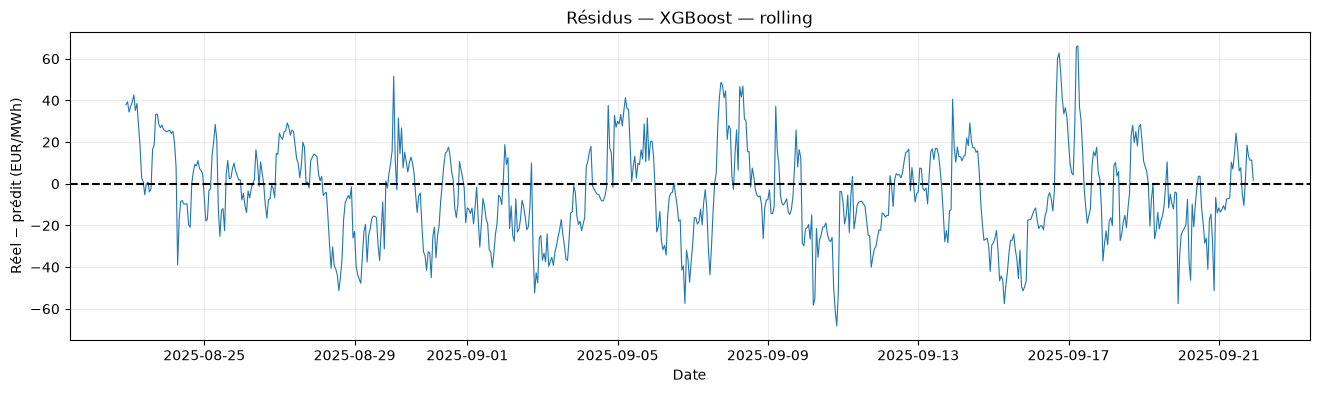

In [7]:
best_model_name = (
    final_walk_forward_benchmark.iloc[0]["model"]
)

print(
    "Meilleur modèle walk-forward :",
    best_model_name,
)

# Dernière fenêtre de 30 jours évaluée
last_window_start = (
    prediction_table.index.max()
    - pd.Timedelta(days=30)
)

plot_data = prediction_table.loc[
    prediction_table.index >= last_window_start
].copy()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    plot_data.index,
    plot_data["y_true"],
    label="Prix réel",
    color="black",
    linewidth=1.1,
)

ax.plot(
    plot_data.index,
    plot_data[best_model_name],
    label=best_model_name,
    color="tab:red",
    linewidth=1.0,
    alpha=0.85,
)

ax.set_title(
    "Prévision walk-forward contre prix réel — dernière fenêtre"
)
ax.set_xlabel("Date")
ax.set_ylabel("Prix day-ahead (EUR/MWh)")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


# Résidus dans le temps
residual = (
    plot_data["y_true"]
    - plot_data[best_model_name]
)

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(
    residual.index,
    residual,
    color="tab:blue",
    linewidth=0.8,
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
)

ax.set_title(
    f"Résidus — {best_model_name}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Réel − prédit (EUR/MWh)")
ax.grid(alpha=0.25)
plt.show()